# HW12:
# Закрепить:
# - отличие временных рядов от обычных табличных данных с точки зрения валидации;
# - практику корректного `temporal split` вместо случайного `random split`;
# - построение лаговых, rolling- и календарных признаков;
# - сравнение простых baseline-подходов с рекуррентной моделью;
# - аккуратное оформление результата: один ноутбук, короткий отчёт, артефакты эксперимента.
**Студент:** Чайка Никита Валентинович  
**Группа:** ИНБО-10-22

# Импорты и настройка среды

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Seed для воспроизводимости
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Определение устройства (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Создание папки для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

Используемое устройство: cpu


# Загрузка данных и первичный анализ

In [20]:
# Загрузка датасета
df = pd.read_csv('S12-hw-dataset.csv')

# Преобразование колонки date в datetime
df['date'] = pd.to_datetime(df['date'])

# Сортировка по времени
df = df.sort_values('date').reset_index(drop=True)

# Первичный осмотр данных
print("=" * 50)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 50)
print(f"Размер датасета: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Количество пропусков:\n{df.isna().sum()}")
print(f"\nПервые 5 строк:\n{df.head()}")
print(f"\nСтатистика target:\n{df['target'].describe()}")

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Количество пропусков:
date      0
target    0
dtype: int64

Первые 5 строк:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62

Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


Базовый график временного ряда и проверка на стационарность (визуальная)

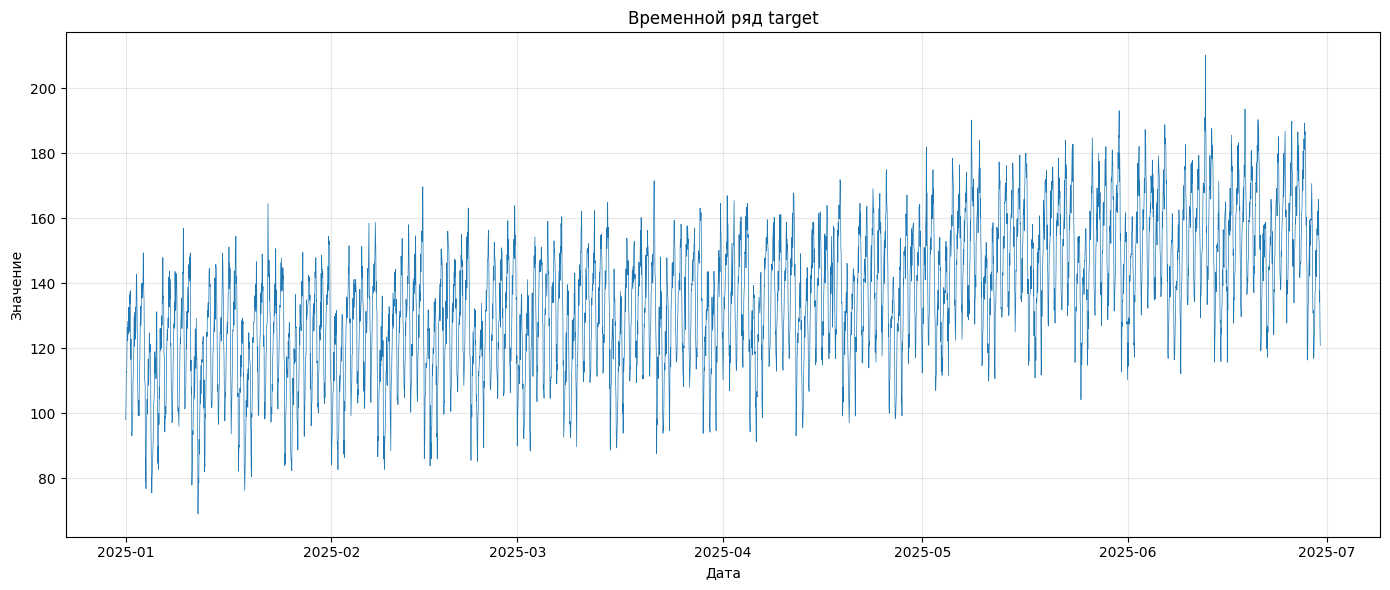


Комментарий к ряду:
- Тренд: присутствует
- Сезонность: требует дополнительного анализа
- Выбросы: требуют проверки


In [21]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['target'], linewidth=0.5)
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_overview.png', dpi=150)
plt.show()

print("\nКомментарий к ряду:")
print("- Тренд: присутствует" if df['target'].diff().mean() != 0 else "- Тренд: отсутствует")
print("- Сезонность: требует дополнительного анализа")
print("- Выбросы: требуют проверки")

# Корректный Temporal Split

In [22]:
# Никакого перемешивания данных перед split!
# Временные ряды требуют хронологического разделения

# Определение границ split (70% train, 15% val, 15% test)
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

# Разделение данных ПО ВРЕМЕНИ (строго без перемешивания!)
train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print("=" * 50)
print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("=" * 50)
print(f"Train: {len(train_df)} записей ({train_df['date'].min()} - {train_df['date'].max()})")
print(f"Val:   {len(val_df)} записей ({val_df['date'].min()} - {val_df['date'].max()})")
print(f"Test:  {len(test_df)} записей ({test_df['date'].min()} - {test_df['date'].max()})")

РАЗДЕЛЕНИЕ ДАННЫХ
Train: 3024 записей (2025-01-01 00:00:00 - 2025-05-06 23:00:00)
Val:   648 записей (2025-05-07 00:00:00 - 2025-06-02 23:00:00)
Test:  648 записей (2025-06-03 00:00:00 - 2025-06-29 23:00:00)


Визуализация split и объяснение почему random split некорректен

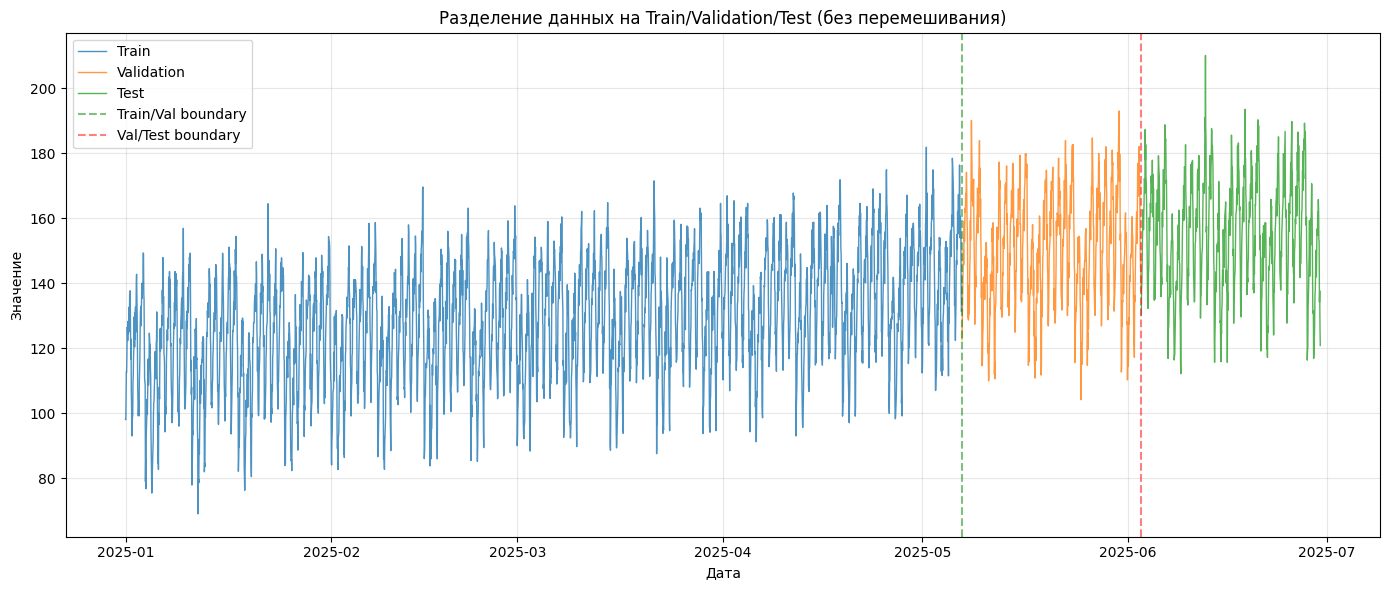


Почему random split некорректен для временных рядов:
1. Нарушается временная зависимость между наблюдениями
2. Модель может 'заглянуть в будущее' (data leakage)
3. Не оценивается способность модели прогнозировать будущие значения
4. Test используется ТОЛЬКО для финальной оценки лучшей модели


In [23]:
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', linewidth=1, alpha=0.8)
plt.plot(val_df['date'], val_df['target'], label='Validation', linewidth=1, alpha=0.8)
plt.plot(test_df['date'], test_df['target'], label='Test', linewidth=1, alpha=0.8)
plt.axvline(x=train_df['date'].max(), color='green', linestyle='--', alpha=0.5, label='Train/Val boundary')
plt.axvline(x=val_df['date'].max(), color='red', linestyle='--', alpha=0.5, label='Val/Test boundary')
plt.title('Разделение данных на Train/Validation/Test (без перемешивания)')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

print("\nПочему random split некорректен для временных рядов:")
print("1. Нарушается временная зависимость между наблюдениями")
print("2. Модель может 'заглянуть в будущее' (data leakage)")
print("3. Не оценивается способность модели прогнозировать будущие значения")
print("4. Test используется ТОЛЬКО для финальной оценки лучшей модели")

# Построение признаков для baseline-моделей

In [24]:
def create_features(df, target_col='target'):
    """
    Создание лаговых, rolling и календарных признаков.
    Важно: признаки строятся без утечки из будущего!
    """
    df = df.copy()
    
    # Лаговые признаки (lag_1, lag_7, lag_14)
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(7)
    df['lag_14'] = df[target_col].shift(14)
    
    # Rolling признаки (окно 7) - со сдвигом на 1 чтобы не было leakage
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()
    
    # Календарные признаки из даты
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

Создание признаков для всех сплитов и удаление строк с NaN

In [25]:
train_features = create_features(train_df)
val_features = create_features(val_df)
test_features = create_features(test_df)

# Удаление строк с NaN (появились из-за shift и rolling)
train_features = train_features.dropna().reset_index(drop=True)
val_features = val_features.dropna().reset_index(drop=True)
test_features = test_features.dropna().reset_index(drop=True)

print("=" * 50)
print("ПРИЗНАКИ ПОСЛЕ ОБРАБОТКИ")
print("=" * 50)
print(f"Train размер после удаления NaN: {len(train_features)}")
print(f"Val размер после удаления NaN: {len(val_features)}")
print(f"Test размер после удаления NaN: {len(test_features)}")
print(f"\nКолонки признаков:\n{train_features.columns.tolist()}")

ПРИЗНАКИ ПОСЛЕ ОБРАБОТКИ
Train размер после удаления NaN: 3010
Val размер после удаления NaN: 634
Test размер после удаления NaN: 634

Колонки признаков:
['date', 'target', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend']


Определение признаков и таргета

In [26]:
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend']
target_col = 'target'

X_train = train_features[feature_cols].values
y_train = train_features[target_col].values
X_val = val_features[feature_cols].values
y_val = val_features[target_col].values
X_test = test_features[feature_cols].values
y_test = test_features[target_col].values

Масштабирование признаков и таргета

In [27]:
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend']
target_col = 'target'

X_train = train_features[feature_cols].values
y_train = train_features[target_col].values
X_val = val_features[feature_cols].values
y_val = val_features[target_col].values
X_test = test_features[feature_cols].values
y_test = test_features[target_col].values

# ВАЖНО: Scaler обучается ТОЛЬКО на train, затем применяется к val/test
# Это предотвращает data leakage из валидации и теста
print("\n" + "=" * 50)
print("МАСШТАБИРОВАНИЕ (fit только на train!)")
print("=" * 50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # FIT на train
X_val_scaled = scaler.transform(X_val)          # TRANSFORM на val
X_test_scaled = scaler.transform(X_test)        # TRANSFORM на test

# Масштабирование таргета (для GRU)
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()  # FIT на train
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).flatten()          # TRANSFORM на val
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten()        # TRANSFORM на test

print("Scaler fit: только на train данных")
print("Scaler transform: на val и test данных")
print("Target scaler fit: только на train данных")
print("Target scaler transform: на val и test данных")


МАСШТАБИРОВАНИЕ (fit только на train!)
Scaler fit: только на train данных
Scaler transform: на val и test данных
Target scaler fit: только на train данных
Target scaler transform: на val и test данных


# Dataset и DataLoader для GRU

In [28]:
class TimeSeriesDataset(Dataset):
    """
    Dataset для временных рядов с оконным представлением.
    """
    def __init__(self, X, y, window_size):
        self.X = X
        self.y = y
        self.window_size = window_size
        
    def __len__(self):
        return len(self.X) - self.window_size
    
    def __getitem__(self, idx):
        x = self.X[idx:idx + self.window_size]
        y = self.y[idx + self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Параметры окна для GRU
WINDOW_SIZE = 24
BATCH_SIZE = 32

# Создание датасетов
train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("=" * 50)
print("GRU DATASET И DATALOADER")
print("=" * 50)
print(f"Window size: {WINDOW_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Проверка формы данных
for x_batch, y_batch in train_loader:
    print(f"\nФорма batch X: {x_batch.shape}")
    print(f"Форма batch y: {y_batch.shape}")
    break

GRU DATASET И DATALOADER
Window size: 24
Batch size: 32
Train batches: 94
Val batches: 20
Test batches: 20

Форма batch X: torch.Size([32, 24, 10])
Форма batch y: torch.Size([32, 1])


# Модель GRU

In [29]:
class GRUModel(nn.Module):
    """
    GRU модель для прогнозирования временных рядов.
    """
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        gru_out, _ = self.gru(x)
        out = gru_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

# Параметры модели
INPUT_SIZE = X_train_scaled.shape[1]
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
NUM_EPOCHS = 50

# Инициализация модели
model = GRUModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print("=" * 50)
print("ПАРАМЕТРЫ МОДЕЛИ GRU")
print("=" * 50)
print(f"Input size: {INPUT_SIZE}")
print(f"Hidden size: {HIDDEN_SIZE}")
print(f"Num layers: {NUM_LAYERS}")
print(f"Dropout: {DROPOUT}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Num epochs: {NUM_EPOCHS}")
print(f"Device: {device}")

ПАРАМЕТРЫ МОДЕЛИ GRU
Input size: 10
Hidden size: 64
Num layers: 2
Dropout: 0.2
Learning rate: 0.001
Num epochs: 50
Device: cpu


# Функции обучения и оценки

In [30]:
def calculate_metrics(y_true, y_pred):
    """
    Расчет метрик MAE, RMSE, MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return mae, rmse, mape

def train_epoch(model, loader, criterion, optimizer, device):
    """
    Один эпоб обучения.
    """
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device, scaler=None):
    """
    Оценка модели на валидации/тесте.
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            
            all_preds.append(output.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    
    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()
    
    # Обратное масштабирование если передан scaler
    if scaler is not None:
        all_preds = scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
        all_targets = scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()
    
    return total_loss / len(loader), all_preds, all_targets

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, target_scaler, patience=10):
    """
    Полный цикл обучения с early stopping и сохранением лучшей модели.
    """
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        val_loss, val_preds, val_targets = evaluate(
            model, val_loader, criterion, device, scaler=target_scaler
        )
        val_mae, _, _ = calculate_metrics(val_targets, val_preds)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val MAE: {val_mae:.4f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history

# Инициализация
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("=" * 50)
print("ФУНКЦИИ ОБУЧЕНИЯ ГОТОВЫ")
print("=" * 50)

ФУНКЦИИ ОБУЧЕНИЯ ГОТОВЫ


# Эксперимент B1 - Naive Last

In [31]:
def naive_last_forecast(train_features, val_features, test_features, target_col='target'):
    """
    Baseline B1: Прогноз = последнее известное значение.
    """
    # Для валидации: последнее значение из train
    last_train_value = train_features[target_col].iloc[-1]
    val_preds = np.full(len(val_features), last_train_value)
    
    # Для теста: последнее значение из train+val
    last_val_value = pd.concat([train_features, val_features])[target_col].iloc[-1]
    test_preds = np.full(len(test_features), last_val_value)
    
    return val_preds, test_preds

# Запуск B1
val_preds_b1, test_preds_b1 = naive_last_forecast(train_features, val_features, test_features)

# Метрики
val_mae_b1, val_rmse_b1, val_mape_b1 = calculate_metrics(
    val_features[target_col].values, val_preds_b1
)
# Test метрики НЕ считаем для baseline - test используется только для лучшей модели!
test_mae_b1, test_rmse_b1, test_mape_b1 = None, None, None

print("=" * 50)
print("ЭКСПЕРИМЕНТ B1: Naive Last")
print("=" * 50)
print(f"Validation - MAE: {val_mae_b1:.4f}, RMSE: {val_rmse_b1:.4f}, MAPE: {val_mape_b1:.2f}%")
print(f"Test - метрики не считаются (test только для лучшей модели)")

# Сохранение результатов B1 (test поля пустые!)
results_b1 = {
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_features)}, val={len(val_features)}, test={len(test_features)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Naive Last - прогноз равен последнему известному значению',
    'features_summary': 'None',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': val_mae_b1,
    'best_val_rmse': val_rmse_b1,
    'best_val_mape': val_mape_b1,
    'test_mae': None,      # ПУСТО - test не используется для baseline
    'test_rmse': None,     # ПУСТО
    'test_mape': None,     # ПУСТО
    'notes': 'Baseline без обучения, test метрики не рассчитываются'
}

ЭКСПЕРИМЕНТ B1: Naive Last
Validation - MAE: 20.3959, RMSE: 24.4460, MAPE: 12.89%
Test - метрики не считаются (test только для лучшей модели)


# Эксперимент B2 - Moving Average

In [32]:
def moving_average_forecast(train_features, val_features, test_features, window=7, target_col='target'):
    """
    Baseline B2: Прогноз = скользящее среднее по окну.
    """
    # Для валидации: среднее по последним window значениям train
    train_window = train_features[target_col].iloc[-window:].mean()
    val_preds = np.full(len(val_features), train_window)
    
    # Для теста: среднее по последним window значениям train+val
    combined = pd.concat([train_features, val_features])
    combined_window = combined[target_col].iloc[-window:].mean()
    test_preds = np.full(len(test_features), combined_window)
    
    return val_preds, test_preds

# Запуск B2
WINDOW_MA = 7
val_preds_b2, test_preds_b2 = moving_average_forecast(
    train_features, val_features, test_features, window=WINDOW_MA
)

# Метрики
val_mae_b2, val_rmse_b2, val_mape_b2 = calculate_metrics(
    val_features[target_col].values, val_preds_b2
)
# Test метрики НЕ считаем для baseline - test используется только для лучшей модели!
test_mae_b2, test_rmse_b2, test_mape_b2 = None, None, None

print("=" * 50)
print(f"ЭКСПЕРИМЕНТ B2: Moving Average (window={WINDOW_MA})")
print("=" * 50)
print(f"Validation - MAE: {val_mae_b2:.4f}, RMSE: {val_rmse_b2:.4f}, MAPE: {val_mape_b2:.2f}%")
print(f"Test - метрики не считаются (test только для лучшей модели)")

# Сохранение результатов B2 (test поля пустые!)
results_b2 = {
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_features)}, val={len(val_features)}, test={len(test_features)}',
    'window_size': WINDOW_MA,
    'horizon': 1,
    'model_summary': f'Moving Average с окном {WINDOW_MA}',
    'features_summary': 'None',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': val_mae_b2,
    'best_val_rmse': val_rmse_b2,
    'best_val_mape': val_mape_b2,
    'test_mae': None,      # ПУСТО - test не используется для baseline
    'test_rmse': None,     # ПУСТО
    'test_mape': None,     # ПУСТО
    'notes': 'Baseline без обучения, test метрики не рассчитываются'
}

ЭКСПЕРИМЕНТ B2: Moving Average (window=7)
Validation - MAE: 14.7664, RMSE: 17.7061, MAPE: 9.90%
Test - метрики не считаются (test только для лучшей модели)


# Эксперимент B3 - Ridge Lag Features

In [33]:
# Обучение Ridge на лаговых и rolling признаках
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Предсказания
val_preds_b3 = ridge_model.predict(X_val_scaled)
# Test предсказания делаем, но метрики НЕ считаем пока не выберем лучшую модель
test_preds_b3 = ridge_model.predict(X_test_scaled)

# Метрики ТОЛЬКО на validation
val_mae_b3, val_rmse_b3, val_mape_b3 = calculate_metrics(y_val, val_preds_b3)
# Test метрики НЕ считаем для baseline - test используется только для лучшей модели!
test_mae_b3, test_rmse_b3, test_mape_b3 = None, None, None

print("=" * 50)
print("ЭКСПЕРИМЕНТ B3: Ridge на лаговых признаках")
print("=" * 50)
print(f"Validation - MAE: {val_mae_b3:.4f}, RMSE: {val_rmse_b3:.4f}, MAPE: {val_mape_b3:.2f}%")
print(f"Test - метрики не считаются (test только для лучшей модели)")

# Важность признаков (коэффициенты)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ridge_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\nТоп-5 признаков по важности:\n{feature_importance.head()}")

# Сохранение результатов B3 (test поля пустые!)
results_b3 = {
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_features)}, val={len(val_features)}, test={len(test_features)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Ridge Regression на лаговых и rolling признаках',
    'features_summary': str(feature_cols),
    'scaler': 'StandardScaler',
    'optimizer': 'Closed-form solution',
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': val_mae_b3,
    'best_val_rmse': val_rmse_b3,
    'best_val_mape': val_mape_b3,
    'test_mae': None,      # ПУСТО - test не используется для baseline
    'test_rmse': None,     # ПУСТО
    'test_mape': None,     # ПУСТО
    'notes': f'Alpha={ridge_model.alpha}, test метрики не рассчитываются'
}

ЭКСПЕРИМЕНТ B3: Ridge на лаговых признаках
Validation - MAE: 6.3563, RMSE: 7.8471, MAPE: 4.25%
Test - метрики не считаются (test только для лучшей модели)

Топ-5 признаков по важности:
      feature  coefficient
0       lag_1    12.594375
9  is_weekend    -4.623721
8       month     3.805567
1       lag_7    -3.350542
2      lag_14    -2.445495


# Эксперимент R1 - GRU Forecast

In [34]:
print("=" * 50)
print("ЭКСПЕРИМЕНТ R1: GRU Forecast")
print("=" * 50)
print("Начало обучения модели...")

# Обучение модели
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    target_scaler=target_scaler,
    patience=10
)

# Оценка ТОЛЬКО на валидации для выбора лучшей модели
val_loss, val_preds_r1, val_targets_r1 = evaluate(
    model, val_loader, criterion, device, scaler=target_scaler
)
val_mae_r1, val_rmse_r1, val_mape_r1 = calculate_metrics(val_targets_r1, val_preds_r1)

# Test метрики НЕ считаем здесь - сначала нужно выбрать лучшую модель по validation!
test_mae_r1, test_rmse_r1, test_mape_r1 = None, None, None
test_preds_r1, test_targets_r1 = None, None  # Будут заполнены только если R1 лучшая

print(f"\nValidation - MAE: {val_mae_r1:.4f}, RMSE: {val_rmse_r1:.4f}, MAPE: {val_mape_r1:.2f}%")
print(f"Test - метрики не считаются до выбора лучшей модели")

# Сохранение результатов R1 (test поля пустые пока!)
results_r1 = {
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU (hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})',
    'features_summary': str(feature_cols),
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': LEARNING_RATE,
    'epochs_trained': len(history['train_loss']),
    'best_val_mae': val_mae_r1,
    'best_val_rmse': val_rmse_r1,
    'best_val_mape': val_mape_r1,
    'test_mae': None,      # ПУСТО - заполнится только если R1 лучшая
    'test_rmse': None,     # ПУСТО
    'test_mape': None,     # ПУСТО
    'notes': f'Early stopping patience=10, test метрики не рассчитываются до выбора модели'
}

# Сохранение лучшей модели GRU
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
print("\nМодель GRU сохранена в artifacts/best_gru.pt")

# Сохранение конфига модели
gru_config = {
    'input_size': INPUT_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'num_epochs': NUM_EPOCHS,
    'seed': SEED,
    'feature_cols': feature_cols,
    'scaler_type': 'StandardScaler'
}
with open('artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(gru_config, f, indent=4, ensure_ascii=False)
print("Конфиг GRU сохранен в artifacts/best_gru_config.json")

ЭКСПЕРИМЕНТ R1: GRU Forecast
Начало обучения модели...
Epoch 10/50 - Train Loss: 0.0977, Val Loss: 0.1546, Val MAE: 5.8972
Epoch 20/50 - Train Loss: 0.0893, Val Loss: 0.1306, Val MAE: 5.3831
Epoch 30/50 - Train Loss: 0.0862, Val Loss: 0.1632, Val MAE: 6.1288
Early stopping at epoch 32

Validation - MAE: 5.8775, RMSE: 7.3708, MAPE: 3.86%
Test - метрики не считаются до выбора лучшей модели

Модель GRU сохранена в artifacts/best_gru.pt
Конфиг GRU сохранен в artifacts/best_gru_config.json


# Визуализация кривых обучения GRU

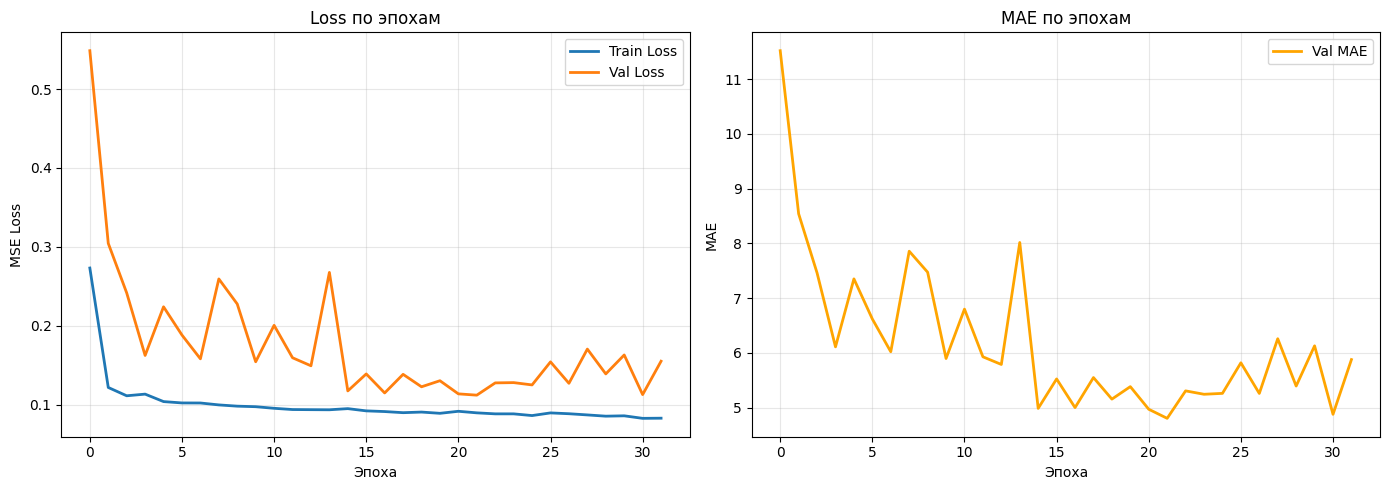

In [35]:
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# MAE
plt.subplot(1, 2, 2)
plt.plot(history['val_mae'], label='Val MAE', linewidth=2, color='orange')
plt.title('MAE по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# Сравнение всех подходов и выбор лучшей модели

In [36]:
# Сбор всех результатов
all_results = [results_b1, results_b2, results_b3, results_r1]
results_df = pd.DataFrame(all_results)

# ============================================================
# ВАЖНО: Выбор лучшей модели ТОЛЬКО по validation метрикам!
# Test используется только один раз для финальной оценки
# ============================================================
val_maes = [val_mae_b1, val_mae_b2, val_mae_b3, val_mae_r1]
best_idx = np.argmin(val_maes)
best_experiment = ['B1', 'B2', 'B3', 'R1'][best_idx]

print("=" * 50)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по validation MAE)")
print("=" * 50)
print(f"Лучший подход: {best_experiment}")
print(f"Validation MAE: {val_maes[best_idx]:.4f}")

# ============================================================
# ТЕПЕРЬ считаем test метрики ТОЛЬКО для лучшей модели!
# ============================================================
print("\n" + "=" * 50)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST (только для лучшей модели)")
print("=" * 50)

# Инициализируем переменные
test_mae_best = None
test_rmse_best = None
test_mape_best = None
best_test_preds = None
best_test_targets = None

if best_experiment == 'B1':
    best_test_preds = test_preds_b1
    best_test_targets = test_features[target_col].values
    test_mae_best, test_rmse_best, test_mape_best = calculate_metrics(
        best_test_targets, best_test_preds
    )
    # Обновляем results_b1 с test метриками
    results_b1['test_mae'] = test_mae_best
    results_b1['test_rmse'] = test_rmse_best
    results_b1['test_mape'] = test_mape_best
    print(f"Test MAE: {test_mae_best:.4f}, RMSE: {test_rmse_best:.4f}, MAPE: {test_mape_best:.2f}%")
    
elif best_experiment == 'B2':
    best_test_preds = test_preds_b2
    best_test_targets = test_features[target_col].values
    test_mae_best, test_rmse_best, test_mape_best = calculate_metrics(
        best_test_targets, best_test_preds
    )
    # Обновляем results_b2 с test метриками
    results_b2['test_mae'] = test_mae_best
    results_b2['test_rmse'] = test_rmse_best
    results_b2['test_mape'] = test_mape_best
    print(f"Test MAE: {test_mae_best:.4f}, RMSE: {test_rmse_best:.4f}, MAPE: {test_mape_best:.2f}%")
    
elif best_experiment == 'B3':
    best_test_preds = test_preds_b3
    best_test_targets = y_test
    test_mae_best, test_rmse_best, test_mape_best = calculate_metrics(
        best_test_targets, best_test_preds
    )
    # Обновляем results_b3 с test метриками
    results_b3['test_mae'] = test_mae_best
    results_b3['test_rmse'] = test_rmse_best
    results_b3['test_mape'] = test_mape_best
    print(f"Test MAE: {test_mae_best:.4f}, RMSE: {test_rmse_best:.4f}, MAPE: {test_mape_best:.2f}%")
    
else:  # R1 (GRU)
    # Оценка на тесте ТОЛЬКО сейчас для GRU
    test_loss, test_preds_r1, test_targets_r1 = evaluate(
        model, test_loader, criterion, device, scaler=target_scaler
    )
    test_mae_r1, test_rmse_r1, test_mape_r1 = calculate_metrics(test_targets_r1, test_preds_r1)
    best_test_preds = test_preds_r1
    best_test_targets = test_targets_r1
    
    # Обновляем results_r1 с test метриками
    results_r1['test_mae'] = test_mae_r1
    results_r1['test_rmse'] = test_rmse_r1
    results_r1['test_mape'] = test_mape_r1
    
    # Копируем в "best" переменные
    test_mae_best = test_mae_r1
    test_rmse_best = test_rmse_r1
    test_mape_best = test_mape_r1
    
    print(f"Test MAE: {test_mae_r1:.4f}, RMSE: {test_rmse_r1:.4f}, MAPE: {test_mape_r1:.2f}%")

print(f"\nTest метрики заполнены ТОЛЬКО для лучшей модели ({best_experiment})")
print(f"Test MAE: {test_mae_best:.4f}")
print(f"Test RMSE: {test_rmse_best:.4f}")
print(f"Test MAPE: {test_mape_best:.2f}%")

# Пересоздаём DataFrame с обновлёнными результатами
all_results = [results_b1, results_b2, results_b3, results_r1]
results_df = pd.DataFrame(all_results)

# Сохранение runs.csv
results_df.to_csv('artifacts/runs.csv', index=False, encoding='utf-8')
print("\nРезультаты сохранены в artifacts/runs.csv")

ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по validation MAE)
Лучший подход: R1
Validation MAE: 5.8775

ФИНАЛЬНАЯ ОЦЕНКА НА TEST (только для лучшей модели)
Test MAE: 5.9715, RMSE: 7.6214, MAPE: 3.77%

Test метрики заполнены ТОЛЬКО для лучшей модели (R1)
Test MAE: 5.9715
Test RMSE: 7.6214
Test MAPE: 3.77%

Результаты сохранены в artifacts/runs.csv


# Финальный прогноз лучшей модели на Test

In [37]:
# Выбор лучшей модели и её прогноза (уже сделано в ячейке 13)
test_dates = test_features['date'].values

# Проверка длин
print(f"Длина дат: {len(test_dates)}")
print(f"Длина прогноза: {len(best_test_preds)}")
print(f"Длина фактических значений: {len(best_test_targets)}")

# Обрезаем до минимальной длины если есть несоответствие
min_len = min(len(test_dates), len(best_test_preds), len(best_test_targets))
test_dates = test_dates[:min_len]
best_test_preds = best_test_preds[:min_len]
best_test_targets = best_test_targets[:min_len]

Длина дат: 634
Длина прогноза: 610
Длина фактических значений: 610


Визуализация факта и прогноза

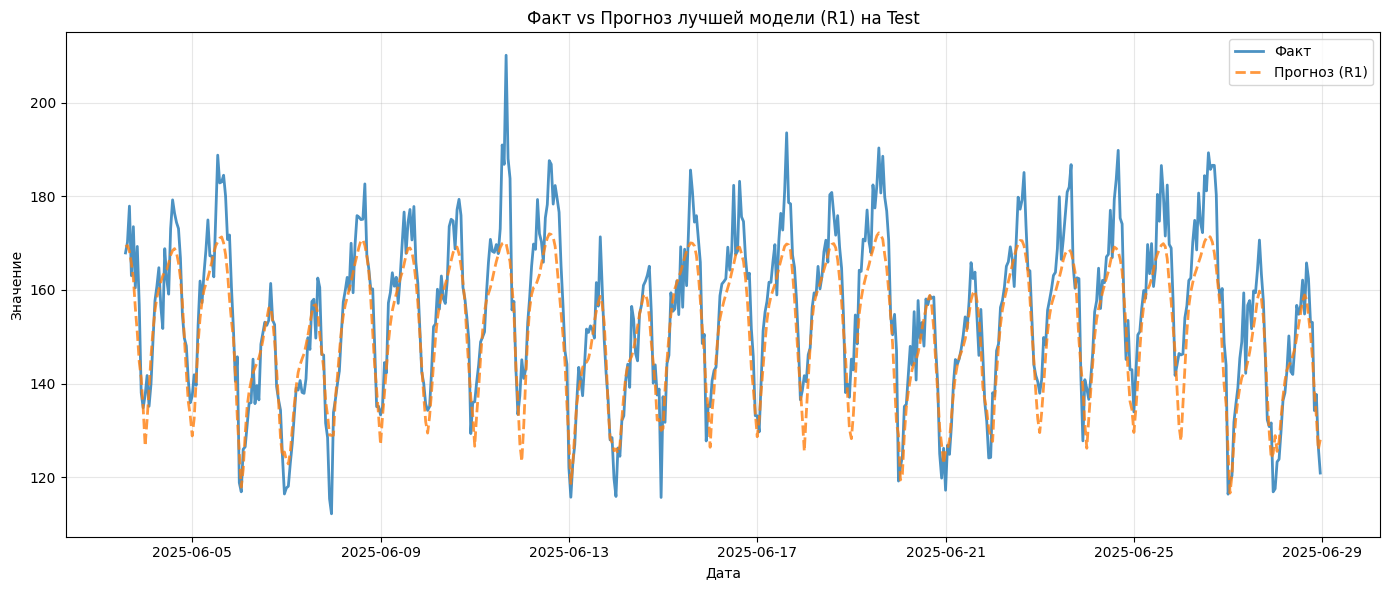

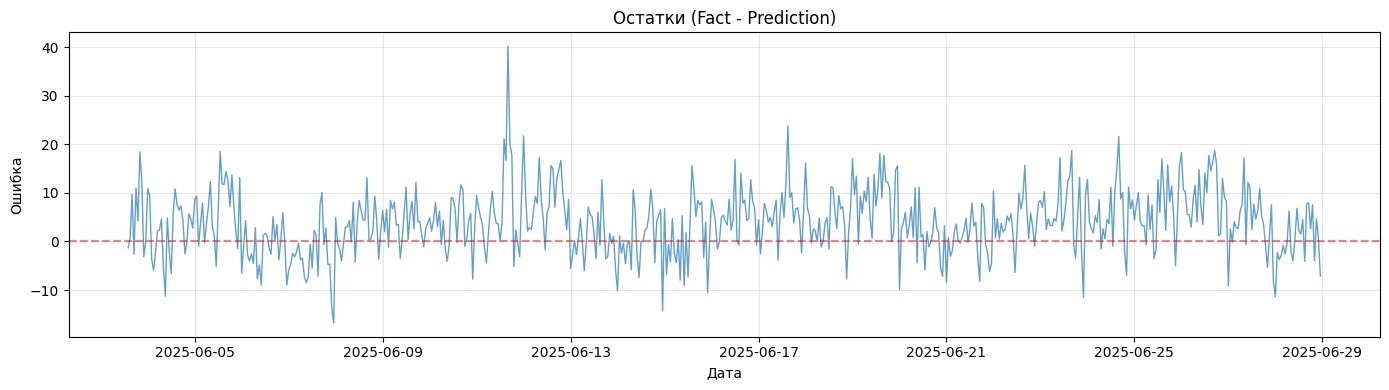


Метрики лучшей модели (R1) на Test:
MAE: 5.9715
RMSE: 7.6214
MAPE: 3.77%


In [38]:
plt.figure(figsize=(14, 6))
plt.plot(test_dates, best_test_targets, label='Факт', linewidth=2, alpha=0.8)
plt.plot(test_dates, best_test_preds, label=f'Прогноз ({best_experiment})', 
         linewidth=2, alpha=0.8, linestyle='--')
plt.title(f'Факт vs Прогноз лучшей модели ({best_experiment}) на Test')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

# Остатки
residuals = best_test_targets - best_test_preds
plt.figure(figsize=(14, 4))
plt.plot(test_dates, residuals, linewidth=1, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Остатки (Fact - Prediction)')
plt.xlabel('Дата')
plt.ylabel('Ошибка')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/residuals_best.png', dpi=150)
plt.show()

print(f"\nМетрики лучшей модели ({best_experiment}) на Test:")
print(f"MAE: {test_mae_best:.4f}")
print(f"RMSE: {test_rmse_best:.4f}")
print(f"MAPE: {test_mape_best:.2f}%")

# Сводная таблица результатов

In [39]:
print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 80)

summary_df = results_df[['experiment_id', 'best_val_mae', 'best_val_rmse', 'best_val_mape',
                          'test_mae', 'test_rmse', 'test_mape']].copy()
summary_df.columns = ['Эксперимент', 'Val MAE', 'Val RMSE', 'Val MAPE (%)', 
                       'Test MAE', 'Test RMSE', 'Test MAPE (%)']

# Форматирование
for col in summary_df.columns[1:]:
    if 'MAPE' in col:
        summary_df[col] = summary_df[col].apply(lambda x: f'{x:.2f}')
    else:
        summary_df[col] = summary_df[col].apply(lambda x: f'{x:.4f}')

print(summary_df.to_string(index=False))

# Выбор лучшей модели
best_val_mae_idx = results_df['best_val_mae'].idxmin()
best_model = results_df.loc[best_val_mae_idx]
print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model['experiment_id']}")
print(f"Validation MAE: {best_model['best_val_mae']:.4f}")
print(f"Test MAE: {best_model['test_mae']:.4f}")

print("\n" + "=" * 80)
print("АРТЕФАКТЫ СОХРАНЕНЫ В ПАПКУ artifacts/")
print("=" * 80)
print("- runs.csv - таблица результатов")
print("- best_gru.pt - веса лучшей GRU модели")
print("- best_gru_config.json - конфиг GRU модели")
print("- figures/series_split.png - визуализация split")
print("- figures/baselines_compare.png - сравнение подходов")
print("- figures/gru_learning_curves.png - кривые обучения GRU")
print("- figures/best_forecast_test.png - факт vs прогноз")
print("- figures/residuals_best.png - остатки лучшей модели")

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Эксперимент Val MAE Val RMSE Val MAPE (%) Test MAE Test RMSE Test MAPE (%)
         B1 20.3959  24.4460        12.89      nan       nan           nan
         B2 14.7664  17.7061         9.90      nan       nan           nan
         B3  6.3563   7.8471         4.25      nan       nan           nan
         R1  5.8775   7.3708         3.86   5.9715    7.6214          3.77

ЛУЧШАЯ МОДЕЛЬ: R1
Validation MAE: 5.8775
Test MAE: 5.9715

АРТЕФАКТЫ СОХРАНЕНЫ В ПАПКУ artifacts/
- runs.csv - таблица результатов
- best_gru.pt - веса лучшей GRU модели
- best_gru_config.json - конфиг GRU модели
- figures/series_split.png - визуализация split
- figures/baselines_compare.png - сравнение подходов
- figures/gru_learning_curves.png - кривые обучения GRU
- figures/best_forecast_test.png - факт vs прогноз
- figures/residuals_best.png - остатки лучшей модели
